### Importación de datos



In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [5]:
# Cálculo de facturación total
tienda['Total'] = tienda['Precio'] + tienda['Costo de envío']
facturacion_total = tienda['Total'].sum()
facturacion_total

np.float64(1212258300.0)

In [6]:
# Facturación por lugar de compra
facturacion_por_ciudad = tienda.groupby('Lugar de Compra')['Total'].sum().sort_values(ascending=False)
facturacion_por_ciudad


,Total
Lugar de Compra,
Bogotá,463439800.0
Medellín,312738700.0
Cali,162651900.0
Pereira,59194000.0
Cúcuta,39926100.0
Barranquilla,34685800.0
Cartagena,23495800.0
Riohacha,19487000.0
Bucaramanga,18527400.0


# 2. Ventas por categoría

In [8]:
ventas_categoria1 = tienda['Categoría del Producto'].value_counts()
ventas_categoria2 = tienda2['Categoría del Producto'].value_counts()
ventas_categoria3 = tienda3['Categoría del Producto'].value_counts()
ventas_categoria4 = tienda4['Categoría del Producto'].value_counts()

print("Tienda 1")
print(ventas_categoria1)

print("\nTienda 2")
print(ventas_categoria2)

print("\nTienda 3")
print(ventas_categoria3)

print("\nTienda 4")
print(ventas_categoria4)

Tienda 1
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Tienda 2
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Tienda 3
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64

Tienda 4
Categoría del Producto
Muebles                    480
Electrónicos    

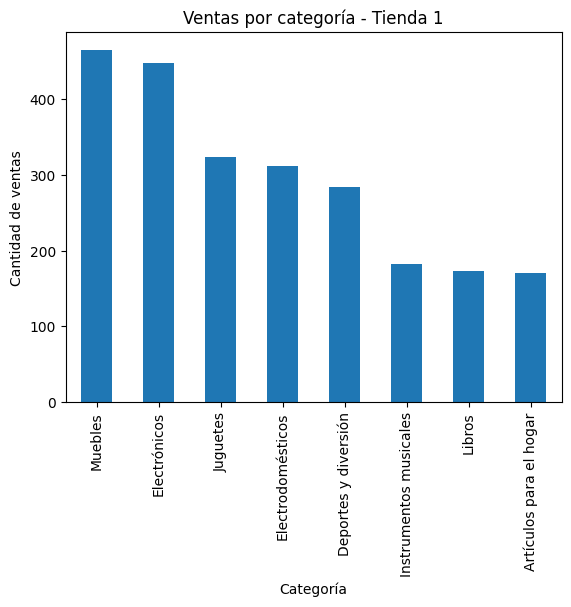

In [10]:
import matplotlib.pyplot as plt

ventas_categoria1.plot(kind='bar')

plt.title('Ventas por categoría - Tienda 1')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de ventas')

plt.show()


# 3. Calificación promedio de la tienda


In [11]:
# Calificación promedio de la tienda
calificacion_promedio = tienda['Calificación'].mean()
calificacion_promedio

np.float64(3.976685036032217)

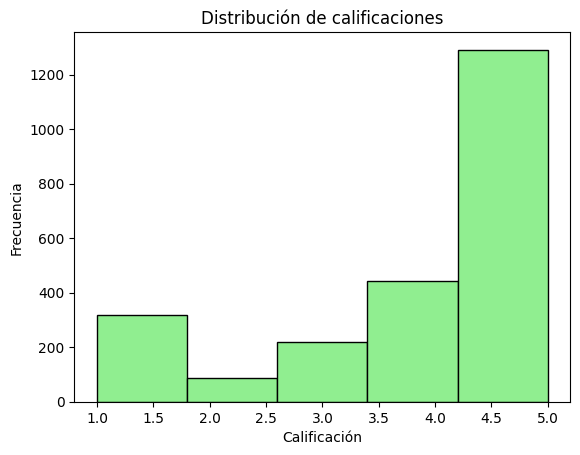

In [12]:
import matplotlib.pyplot as plt

plt.hist(tienda['Calificación'], bins=5, color='lightgreen', edgecolor='black')
plt.title('Distribución de calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Frecuencia')
plt.show()

# 4. Productos más y menos vendidos

In [13]:
# Productos más y menos vendidos
productos_vendidos = tienda['Producto'].value_counts()

producto_mas_vendido = productos_vendidos.idxmax()
producto_menos_vendido = productos_vendidos.idxmin()

producto_mas_vendido, producto_menos_vendido


('Microondas', 'Auriculares con micrófono')

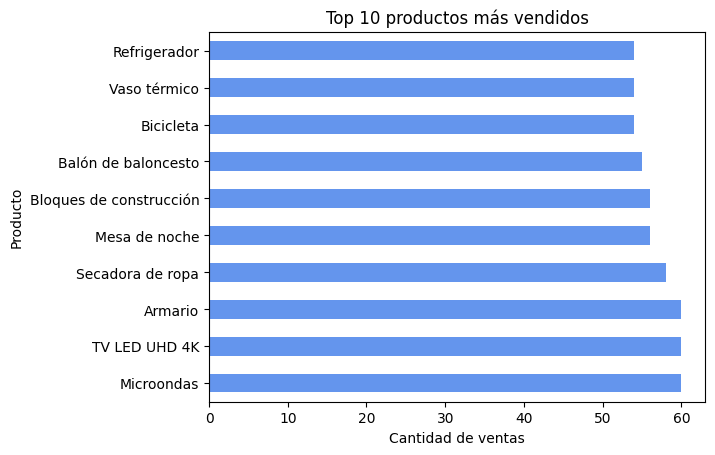

In [14]:
import matplotlib.pyplot as plt

# Top 10 productos más vendidos
top_productos = productos_vendidos.head(10)

top_productos.plot(kind='barh', color='cornflowerblue')
plt.title('Top 10 productos más vendidos')
plt.xlabel('Cantidad de ventas')
plt.ylabel('Producto')
plt.show()


# 5. Envío promedio por tienda

In [15]:
# Envío promedio por tienda (por vendedor)
envio_promedio_por_vendedor = tienda.groupby('Vendedor')['Costo de envío'].mean().sort_values(ascending=False)
envio_promedio_por_vendedor


,Costo de envío
Vendedor,
Maria Alfonso,30726.011561
Rafael Acosta,29991.228070
Felipe Santos,28477.058824
Lucas Olivera,27269.277108
Juliana Costa,27101.775148
Pedro Gomez,26021.301775
Santiago Silva,26006.944444
Juan Fernandez,25700.000000
Beatriz Morales,25680.000000


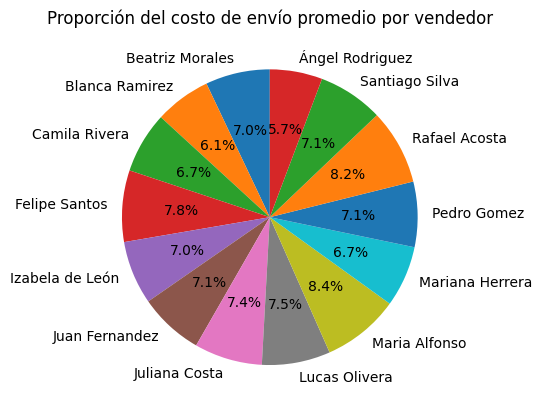

In [18]:
import matplotlib.pyplot as plt

# Envío promedio por vendedor
envio_promedio_por_vendedor = tienda.groupby('Vendedor')['Costo de envío'].mean()

plt.pie(envio_promedio_por_vendedor,
        labels=envio_promedio_por_vendedor.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Proporción del costo de envío promedio por vendedor')
plt.show()
